# Road Crack Detection — YOLO training workflow

Same structure as the trash-on-road notebook: download → inspect → remap/filter →
group-aware re-split → verify → train → validate → predict.

Dataset: `new-workspace-zyrs3/road-crack-4vwph` version 3 (Roboflow Universe).

**Before running:** Runtime → Change runtime type → GPU (T4 is enough).


**1 — Install dependencies**

In [ ]:
!pip install -U ultralytics roboflow pyyaml matplotlib opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfu

**2 — Imports and GPU check**

In [ ]:
import os
import glob
import yaml
import random
import shutil
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import cv2
import torch

from ultralytics import YOLO

print("Ultralytics imported successfully!")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available. Enable GPU in Runtime → Change runtime type.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics imported successfully!
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


**3 — Mount Google Drive** (checkpoints survive a disconnect)

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


**4 — Project folder on Drive**

In [ ]:
PROJECT_ROOT = Path("/content/drive/MyDrive/PTM/road_crack_training")

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

print("Project directory:")
print(PROJECT_ROOT)

Project directory:
/content/drive/MyDrive/PTM/road_crack_training


**5 — Download the dataset from Roboflow**

Workspace `new-workspace-zyrs3`, project `road-crack-4vwph`, version `3`.
Replace the API key with your own from Roboflow → Settings → API Keys if this one expires.

In [ ]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = "XgnrdkrD2jrcSAiJoiHY"   # <- your Roboflow private API key

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

crack_project = rf.workspace(
    "chhhuuuuue"
).project(
    "crack-g4hd4"
)

crack_version = crack_project.version(2)

dataset = crack_version.download(
    "yolov8",                                  # use "yolov8" for boxes; the loader below
    location="/content/raw_datasets/road_crack"  # auto-detects polygons if the export has them
)

DATASET_DIR = Path("/content/raw_datasets/road_crack")

print("✅ Dataset downloaded!")
print("Dataset location:", DATASET_DIR)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/raw_datasets/road_crack in yolov8:: 100%|██████████| 729/729 [00:00<00:00, 6646.53it/s]

✅ Dataset downloaded!
Dataset location: /content/raw_datasets/road_crack


**6 — Look at what came down**

In [ ]:
print("Top-level contents:")

for item in sorted(DATASET_DIR.iterdir()):
    print(" -", item.name)

print("\nDirectory structure:")

for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(str(DATASET_DIR), "").count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

Top-level contents:
 - README.dataset.txt
 - README.roboflow.txt
 - data.yaml
 - train
 - valid

Directory structure:
road_crack/
  valid/
    images/
    labels/
  train/
    images/
    labels/


**7 — Locate data.yaml**

In [ ]:
yaml_files = list(DATASET_DIR.glob("*.yaml"))

print("YAML files found:")

for f in yaml_files:
    print(" -", f)

if not yaml_files:
    raise FileNotFoundError(
        f"No data.yaml found inside {DATASET_DIR}"
    )

DATA_YAML = yaml_files[0]

print("\nUsing:")
print(DATA_YAML)

YAML files found:
 - /content/raw_datasets/road_crack/data.yaml

Using:
/content/raw_datasets/road_crack/data.yaml


**8 — Read the classes**

In [ ]:
with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

print("data.yaml contents:\n")
print(yaml.safe_dump(data_config, sort_keys=False))

print("\nClasses:")
print(data_config.get("names"))

print("\nNumber of classes:")
print(data_config.get("nc"))

data.yaml contents:

names:
- crack
nc: 1
roboflow:
  license: CC BY 4.0
  project: crack-g4hd4
  url: https://universe.roboflow.com/chhhuuuuue/crack-g4hd4/dataset/2
  version: 2
  workspace: chhhuuuuue
test: ../test/images
train: ../train/images
val: ../valid/images


Classes:
['crack']

Number of classes:
1


**9 — Resolve the split directories**

In [ ]:
def resolve_split_dir(dataset_dir: Path, candidates):
    for name in candidates:
        p = dataset_dir / name / "images"
        if p.exists():
            return dataset_dir / name
    return None

train_split = resolve_split_dir(DATASET_DIR, ["train"])
val_split = resolve_split_dir(DATASET_DIR, ["valid", "val"])
test_split = resolve_split_dir(DATASET_DIR, ["test"])

TRAIN_DIR = (train_split / "images") if train_split else None
VAL_DIR = (val_split / "images") if val_split else None
TEST_DIR = (test_split / "images") if test_split else None

print("TRAIN_DIR:", TRAIN_DIR, "| exists:", TRAIN_DIR.exists() if TRAIN_DIR else False)
print("VAL_DIR:  ", VAL_DIR, "| exists:", VAL_DIR.exists() if VAL_DIR else False)
print("TEST_DIR: ", TEST_DIR, "| exists:", TEST_DIR.exists() if TEST_DIR else False)

if TRAIN_DIR is None or VAL_DIR is None:
    raise FileNotFoundError("Could not resolve train/valid split directories — check the dataset structure above.")

TRAIN_DIR: /content/raw_datasets/road_crack/train/images | exists: True
VAL_DIR:   /content/raw_datasets/road_crack/valid/images | exists: True
TEST_DIR:  None | exists: False


**10 — Count images and labels per split**

In [ ]:
def count_images_labels(split_dir):
    if split_dir is None:
        return 0, 0
    image_dir = split_dir
    label_dir = split_dir.parent / "labels"
    n_images = len(list(image_dir.glob("*.*")))
    n_labels = len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0
    return n_images, n_labels

for name, split_dir in [("train", TRAIN_DIR), ("valid", VAL_DIR), ("test", TEST_DIR)]:
    n_img, n_lbl = count_images_labels(split_dir)
    print(f"{name:>6}: {n_img} images, {n_lbl} labels")

 train: 305 images, 305 labels
 valid: 55 images, 55 labels
  test: 0 images, 0 labels


**12 — Detection or segmentation?** (5 tokens = box, more = polygon)

In [ ]:
LABEL_DIR = TRAIN_DIR.parent / "labels"
label_files = list(LABEL_DIR.glob("*.txt"))

if not label_files:
    raise RuntimeError(f"No label files found in {LABEL_DIR}")

sample_label = None
for f in label_files:
    if f.read_text().strip():
        sample_label = f
        break
if sample_label is None:
    raise RuntimeError("All label files are empty.")

lines = [l for l in sample_label.read_text().splitlines() if l.strip()]
first_line_values = lines[0].split() if lines else []

IS_SEGMENTATION = len(first_line_values) > 5

print("Sample label file:", sample_label)
print("Values in first annotation line:", len(first_line_values))
print("Detected label format:", "segmentation" if IS_SEGMENTATION else "detection")

Sample label file: /content/raw_datasets/road_crack/train/labels/10422_1_jpg.rf.6f0aa43683d6322ae4f9b2599dc02cd2.txt
Values in first annotation line: 41
Detected label format: segmentation


**13 — Visualise raw samples with their annotations**

In [ ]:
def get_image_files(image_dir, limit=None):
    image_dir = Path(image_dir)
    files = sorted([
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    ])
    return files

def show_samples(image_dir, n=6):
    image_dir = Path(image_dir)
    images = get_image_files(image_dir)

    if not images:
        print(f"No images found in: {image_dir}")
        return

    names = data_config.get("names")
    if isinstance(names, dict):
        names = [names[k] for k in sorted(names)]

    selected = random.sample(images, min(n, len(images)))
    label_dir = image_dir.parent / "labels"

    fig, axes = plt.subplots(len(selected), 1, figsize=(12, 5 * len(selected)))
    if len(selected) == 1:
        axes = [axes]

    for ax, image_path in zip(axes, selected):
        image = cv2.imread(str(image_path))
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        label_path = label_dir / f"{image_path.stem}.txt"
        ax.imshow(image)
        ax.set_title(image_path.name)
        ax.axis("off")

        if label_path.exists():
            lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
            for line in lines:
                parts = list(map(float, line.split()))
                cls = int(parts[0])
                coords = parts[1:]
                label = names[cls] if names and cls < len(names) else str(cls)

                if len(coords) == 4:
                    # YOLO detection box: x_center, y_center, width, height (normalized)
                    xc, yc, bw, bh = coords
                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    rect = plt.Rectangle((x1, y1), bw * w, bh * h, fill=False, linewidth=2, edgecolor="red")
                    ax.add_patch(rect)
                    ax.text(x1, max(y1 - 5, 0), label, color="red", fontsize=10)

                elif len(coords) >= 6 and len(coords) % 2 == 0:
                    # YOLO segmentation polygon
                    pts = [(coords[i] * w, coords[i + 1] * h) for i in range(0, len(coords), 2)]
                    if len(pts) >= 3:
                        polygon = plt.Polygon(pts, fill=False, linewidth=2, edgecolor="red")
                        ax.add_patch(polygon)

    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, n=6)

**14 — Class map**

Print what the dataset actually ships, then decide what to keep. The default below keeps
everything unchanged. Crack datasets often split into `longitudinal / transverse / alligator /
pothole` style labels — if you want a single `crack` class, point several original names at the
same new name (like the trash notebook merged `Close_full` and `Open_full`).

In [ ]:
ORIGINAL_NAMES = data_config["names"]
if isinstance(ORIGINAL_NAMES, dict):
    ORIGINAL_NAMES = [ORIGINAL_NAMES[k] for k in sorted(ORIGINAL_NAMES)]

print("Original classes in data.yaml:")
for i, n in enumerate(ORIGINAL_NAMES):
    print(f"  {i:>2}  {n}")

# ---- Class filter configuration -------------------------------------------------
# Default: keep every class as-is.
KEEP_MAP = {name: name for name in ORIGINAL_NAMES}

# Example: collapse everything into one class ------------------------------------
# KEEP_MAP = {name: "crack" for name in ORIGINAL_NAMES}
#
# Example: keep cracks, merge surface damage, drop the rest ----------------------
# KEEP_MAP = {
#     "longitudinal": "crack",
#     "transverse":   "crack",
#     "alligator":    "crack",
#     "pothole":      "pothole",
# }

NEW_CLASSES = sorted(set(KEEP_MAP.values()))
NEW_CLASS_ID = {name: i for i, name in enumerate(NEW_CLASSES)}

OLD_ID_TO_NEW_ID = {}
for old_id, old_name in enumerate(ORIGINAL_NAMES):
    if old_name in KEEP_MAP:
        OLD_ID_TO_NEW_ID[old_id] = NEW_CLASS_ID[KEEP_MAP[old_name]]

print("\nMapping:")
for i, n in enumerate(ORIGINAL_NAMES):
    tag = f"KEEP -> {KEEP_MAP[n]} ({OLD_ID_TO_NEW_ID[i]})" if n in KEEP_MAP else "drop"
    print(f"  {i:>2}  {n:<20} {tag}")

print("\nNew classes:", NEW_CLASSES)

missing = [n for n in KEEP_MAP if n not in ORIGINAL_NAMES]
if missing:
    raise ValueError(f"These KEEP_MAP names are not in data.yaml: {missing}")

Original classes in data.yaml:
   0  crack

Mapping:
   0  crack                KEEP -> crack (0)

New classes: ['crack']


**14b — Size threshold: how big is "big enough"?**

Every annotation is measured in fractions of the image, so the numbers survive resizing. Run this
first and look at the histogram before you commit to a threshold in the next cell.

- `length` = longer side of the box (a long crack scores high even if it's hairline-thin)
- `width`  = shorter side (a wide/spalled crack scores high even if it's short)
- `area`   = box area

An annotation is **kept** if it clears *any* of the three thresholds — long OR wide OR large.
There's also an upper bound: a box covering almost the whole frame is very likely a bad label,
not a crack (this is what produced full-frame "crack" boxes at inference time before).

In [ ]:
import math

def parse_annotation(line):
    """Return (old_class_id, xc, yc, bw, bh) in normalised units, for box or polygon labels."""
    parts = line.split()
    old_id = int(float(parts[0]))
    coords = list(map(float, parts[1:]))

    if len(coords) == 4:
        xc, yc, bw, bh = coords
    elif len(coords) >= 6 and len(coords) % 2 == 0:
        xs = coords[0::2]
        ys = coords[1::2]
        x1, x2 = min(xs), max(xs)
        y1, y2 = min(ys), max(ys)
        xc, yc = (x1 + x2) / 2, (y1 + y2) / 2
        bw, bh = x2 - x1, y2 - y1
    else:
        return None

    return old_id, xc, yc, bw, bh


def crack_size(bw, bh):
    """length = longer side, width = shorter side, area = box area (all normalised)."""
    return max(bw, bh), min(bw, bh), bw * bh


# ---- Measure every annotation in the raw training split -------------------------
lengths, widths, areas = [], [], []
raw_label_dir = TRAIN_DIR.parent / "labels"

for lbl in raw_label_dir.glob("*.txt"):
    for line in lbl.read_text().splitlines():
        if not line.strip():
            continue
        parsed = parse_annotation(line)
        if parsed is None:
            continue
        _, _, _, bw, bh = parsed
        L, W, A = crack_size(bw, bh)
        lengths.append(L); widths.append(W); areas.append(A)

print(f"Measured {len(lengths)} annotations\n")

def pct(vals, p):
    vals = sorted(vals)
    return vals[min(int(p / 100 * len(vals)), len(vals) - 1)] if vals else 0

for name, vals in [("length", lengths), ("width", widths), ("area", areas)]:
    print(f"{name:>7}  p10={pct(vals,10):.3f}  p25={pct(vals,25):.3f}  "
          f"median={pct(vals,50):.3f}  p75={pct(vals,75):.3f}  p90={pct(vals,90):.3f}  "
          f"p99={pct(vals,99):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, vals) in zip(axes, [("length (longer side)", lengths),
                                   ("width (shorter side)", widths),
                                   ("area", areas)]):
    ax.hist(vals, bins=50)
    ax.set_title(name)
    ax.set_xlabel("fraction of image")
    ax.set_ylabel("annotations")
plt.tight_layout()
plt.show()

**14c — Set the thresholds and preview what survives**

At `imgsz=768`, `0.25` of the frame is roughly 190 px. Tune until the "kept" percentage looks
right, then look at the side-by-side preview: green solid = kept, faded red dashed = dropped
(too small OR flagged as an oversized/likely-bad label).

In [ ]:
# ---- Crack size filter ----------------------------------------------------------
# Keep an annotation if it clears ANY of these (all as a fraction of image size).
MIN_LENGTH = 0.25    # long crack: longer side >= 25% of the frame
MIN_WIDTH  = 0.06    # wide crack: shorter side >= 6% of the frame
MIN_AREA   = 0.010   # large blob: box covers >= 1% of the frame

# Upper bound: reject boxes that are almost certainly bad labels (e.g. a box drawn
# across the whole frame), which is what produced full-frame "crack" predictions.
MAX_LENGTH = 0.85
MAX_AREA   = 0.60

# If an image contains BOTH a kept crack and a dropped one, the small crack sits in the
# image unlabelled and pushes the model to ignore that texture. That is usually what you
# want here. Set True to throw such mixed images away instead (cleaner, less data).
DROP_MIXED_IMAGES = False


def is_big_enough(bw, bh):
    L, W, A = crack_size(bw, bh)
    if L >= MAX_LENGTH or A >= MAX_AREA:
        return False   # suspiciously huge -> likely a bad annotation, drop it
    return (L >= MIN_LENGTH) or (W >= MIN_WIDTH) or (A >= MIN_AREA)


kept = 0
for L, W, A in zip(lengths, widths, areas):
    if (L >= MAX_LENGTH or A >= MAX_AREA):
        continue
    if L >= MIN_LENGTH or W >= MIN_WIDTH or A >= MIN_AREA:
        kept += 1

print(f"Kept {kept} / {len(lengths)} annotations ({100*kept/max(len(lengths),1):.1f}%)")
print(f"Dropped (too small or too large): {len(lengths) - kept}\n")

# ---- Visual preview -------------------------------------------------------------
def preview_size_filter(image_dir, n=4):
    image_dir = Path(image_dir)
    label_dir = image_dir.parent / "labels"
    images = [p for p in get_image_files(image_dir)
              if (label_dir / f"{p.stem}.txt").exists()
              and (label_dir / f"{p.stem}.txt").read_text().strip()]
    if not images:
        print("No annotated images found.")
        return

    selected = random.sample(images, min(n, len(images)))
    fig, axes = plt.subplots(len(selected), 1, figsize=(12, 5 * len(selected)))
    if len(selected) == 1:
        axes = [axes]

    for ax, image_path in zip(axes, selected):
        image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        ax.imshow(image); ax.axis("off")

        n_keep = n_drop = 0
        for line in (label_dir / f"{image_path.stem}.txt").read_text().splitlines():
            if not line.strip():
                continue
            parsed = parse_annotation(line)
            if parsed is None:
                continue
            _, xc, yc, bw, bh = parsed
            keep = is_big_enough(bw, bh)
            n_keep += keep; n_drop += not keep

            x1, y1 = (xc - bw / 2) * w, (yc - bh / 2) * h
            ax.add_patch(plt.Rectangle(
                (x1, y1), bw * w, bh * h, fill=False,
                linewidth=2.5 if keep else 1.2,
                edgecolor="lime" if keep else "red",
                linestyle="-" if keep else "--",
                alpha=1.0 if keep else 0.6))
            L, W, A = crack_size(bw, bh)
            ax.text(x1, max(y1 - 6, 0), f"{'KEEP' if keep else 'drop'} L={L:.2f} W={W:.2f}",
                    color="lime" if keep else "red", fontsize=9, weight="bold")

        ax.set_title(f"{image_path.name}  —  {n_keep} kept, {n_drop} dropped")

    plt.tight_layout(); plt.show()

preview_size_filter(TRAIN_DIR, n=4)

**15 — Filter, remap, and keep a few backgrounds**

Images with no kept annotation become optional negatives (empty label file). For cracks these are
clean road surfaces — valuable, because they teach the model not to fire on tar lines, shadows,
and lane markings. Keep the ratio modest.

In [ ]:
FILTERED_DIR = Path("/content/datasets/crack_filtered")
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# Fraction of background (no-object) images to keep, relative to positives.
# 0.12 => roughly 12% of the split is backgrounds. Ultralytics suggests 0-10%;
# keep it modest or the model gets shy.
BACKGROUND_RATIO = 0.12

SPLITS = {
    "train": TRAIN_DIR,
    "valid": VAL_DIR,
    "test":  TEST_DIR,
}

random.seed(0)


def filter_split(split_name, image_dir):
    """Keep images with a target class; keep a subset of the rest as backgrounds."""
    if image_dir is None or not Path(image_dir).exists():
        print(f"{split_name}: skipped (not present)")
        return Counter()

    image_dir = Path(image_dir)
    label_dir = image_dir.parent / "labels"

    out_img = FILTERED_DIR / split_name / "images"
    out_lbl = FILTERED_DIR / split_name / "labels"
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)

    counts = Counter()
    kept_images = 0
    bg_candidates = []
    no_label = 0
    n_small = 0          # annotations dropped for being too small or too large
    n_mixed_dropped = 0  # whole images discarded because of DROP_MIXED_IMAGES

    for img_path in sorted(image_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue

        label_path = label_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            no_label += 1
            continue

        kept_lines = []
        dropped_small = 0
        for line in label_path.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            old_id = int(float(parts[0]))
            if old_id not in OLD_ID_TO_NEW_ID:
                continue

            parsed = parse_annotation(line)
            if parsed is None:
                continue
            _, _, _, bw, bh = parsed

            if not is_big_enough(bw, bh):
                dropped_small += 1
                n_small += 1
                continue

            new_id = OLD_ID_TO_NEW_ID[old_id]
            kept_lines.append(" ".join([str(new_id)] + parts[1:]))
            counts[NEW_CLASSES[new_id]] += 1

        if kept_lines and dropped_small and DROP_MIXED_IMAGES:
            n_mixed_dropped += 1
            continue

        if kept_lines:
            shutil.copy2(img_path, out_img / img_path.name)
            (out_lbl / f"{img_path.stem}.txt").write_text("\n".join(kept_lines) + "\n")
            kept_images += 1
        else:
            # nothing left: clean road, or only hairline cracks -> useful negative
            bg_candidates.append(img_path)

    n_bg = int(round(BACKGROUND_RATIO * kept_images))
    random.shuffle(bg_candidates)
    chosen_bg = bg_candidates[:n_bg]

    for img_path in chosen_bg:
        shutil.copy2(img_path, out_img / img_path.name)
        (out_lbl / f"{img_path.stem}.txt").write_text("")   # empty label = background

    print(
        f"{split_name:>6}: {kept_images} positive, {len(chosen_bg)} background "
        f"(from {len(bg_candidates)} candidates), {no_label} unlabelled skipped, "
        f"{n_small} annotations dropped as too small/large, {n_mixed_dropped} mixed images discarded"
    )
    for cls, c in counts.items():
        print(f"         {cls}: {c} boxes")
    return counts


if FILTERED_DIR.exists():
    shutil.rmtree(FILTERED_DIR)

total = Counter()
for split_name, image_dir in SPLITS.items():
    total += filter_split(split_name, image_dir)

print("\nTotal boxes after filtering:")
for cls in NEW_CLASSES:
    print(f"  {cls}: {total[cls]}")

if sum(total.values()) == 0:
    raise RuntimeError("Filtering removed everything — check KEEP_MAP, or loosen MIN_LENGTH / MIN_WIDTH / MIN_AREA / MAX_LENGTH / MAX_AREA.")

**16 — Group-aware re-split**

Roboflow augments one source photo into several files (`<name>_jpg.rf.<hash>`). If augmented
copies of the same photo land in both train and valid, your mAP is fiction. Group on the source
name and split by group.

In [ ]:
VAL_FRACTION = 0.18

def base_group(stem: str) -> str:
    """Roboflow names look like '<original>_jpg.rf.<hash>'. Group on the original."""
    return stem.split(".rf.")[0]

# Pool everything currently in train + valid
pool = {}   # group -> list of (image_path, label_path)
for split in ["train", "valid"]:
    img_dir = FILTERED_DIR / split / "images"
    lbl_dir = FILTERED_DIR / split / "labels"
    if not img_dir.exists():
        continue
    for img in sorted(img_dir.iterdir()):
        if img.suffix.lower() not in IMAGE_EXTS:
            continue
        lbl = lbl_dir / f"{img.stem}.txt"
        pool.setdefault(base_group(img.stem), []).append((img, lbl))

groups = sorted(pool.keys())
random.Random(42).shuffle(groups)

total_images = sum(len(v) for v in pool.values())
target_val = int(round(VAL_FRACTION * total_images))

val_groups, n_val = set(), 0
for g in groups:
    if n_val >= target_val:
        break
    val_groups.add(g)
    n_val += len(pool[g])

# Stage the new split, then swap it in
STAGING = Path("/content/datasets/_resplit")
if STAGING.exists():
    shutil.rmtree(STAGING)
for split in ["train", "valid"]:
    (STAGING / split / "images").mkdir(parents=True, exist_ok=True)
    (STAGING / split / "labels").mkdir(parents=True, exist_ok=True)

for g, items in pool.items():
    split = "valid" if g in val_groups else "train"
    for img, lbl in items:
        shutil.copy2(img, STAGING / split / "images" / img.name)
        if lbl.exists():
            shutil.copy2(lbl, STAGING / split / "labels" / lbl.name)

for split in ["train", "valid"]:
    shutil.rmtree(FILTERED_DIR / split)
    shutil.move(str(STAGING / split), str(FILTERED_DIR / split))
shutil.rmtree(STAGING, ignore_errors=True)

FILTERED_TRAIN = FILTERED_DIR / "train" / "images"
FILTERED_VAL   = FILTERED_DIR / "valid" / "images"
FILTERED_TEST  = FILTERED_DIR / "test"  / "images"

print(f"Re-split {total_images} images across {len(groups)} source photos "
      f"({len(val_groups)} photos held out for validation)\n")

Re-split 360 images across 360 source photos (65 photos held out for validation)



**17 — Verify: class counts, background share, and leakage check**

In [ ]:
valid_ids = set(range(len(NEW_CLASSES)))
bad_ids, split_groups = [], {}

for split in ["train", "valid", "test"]:
    img_dir = FILTERED_DIR / split / "images"
    lbl_dir = FILTERED_DIR / split / "labels"
    if not img_dir.exists():
        print(f"{split:>6}: missing")
        continue

    n_img = len([p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])
    per_class, n_bg = Counter(), 0
    split_groups[split] = set()

    for lbl in sorted(lbl_dir.glob("*.txt")):
        split_groups[split].add(base_group(lbl.stem))
        lines = [l for l in lbl.read_text().splitlines() if l.strip()]
        if not lines:
            n_bg += 1
            continue
        for line in lines:
            cid = int(float(line.split()[0]))
            if cid in valid_ids:
                per_class[NEW_CLASSES[cid]] += 1
            else:
                bad_ids.append((lbl.name, cid))

    print(f"{split:>6}: {n_img} images ({n_bg} background, "
          f"{100*n_bg/max(n_img,1):.0f}%)")
    for cls in NEW_CLASSES:
        print(f"         {cls}: {per_class[cls]} boxes")

print("\nInvalid class ids:", len(bad_ids), bad_ids[:5])

overlap = split_groups.get("train", set()) & split_groups.get("valid", set())
print("Source photos shared between train and valid:", len(overlap))
if overlap:
    raise RuntimeError("Leakage — the same photo appears in both splits.")

for split in ["train", "valid"]:
    if not (FILTERED_DIR / split / "images").exists() or not split_groups.get(split):
        raise RuntimeError(f"{split} split is empty.")

 train: 295 images (0 background, 0%)
         crack: 465 boxes
 valid: 65 images (0 background, 0%)
         crack: 87 boxes
  test: missing

Invalid class ids: 0 []
Source photos shared between train and valid: 0


**18 — Visualise the filtered set with the new class names**

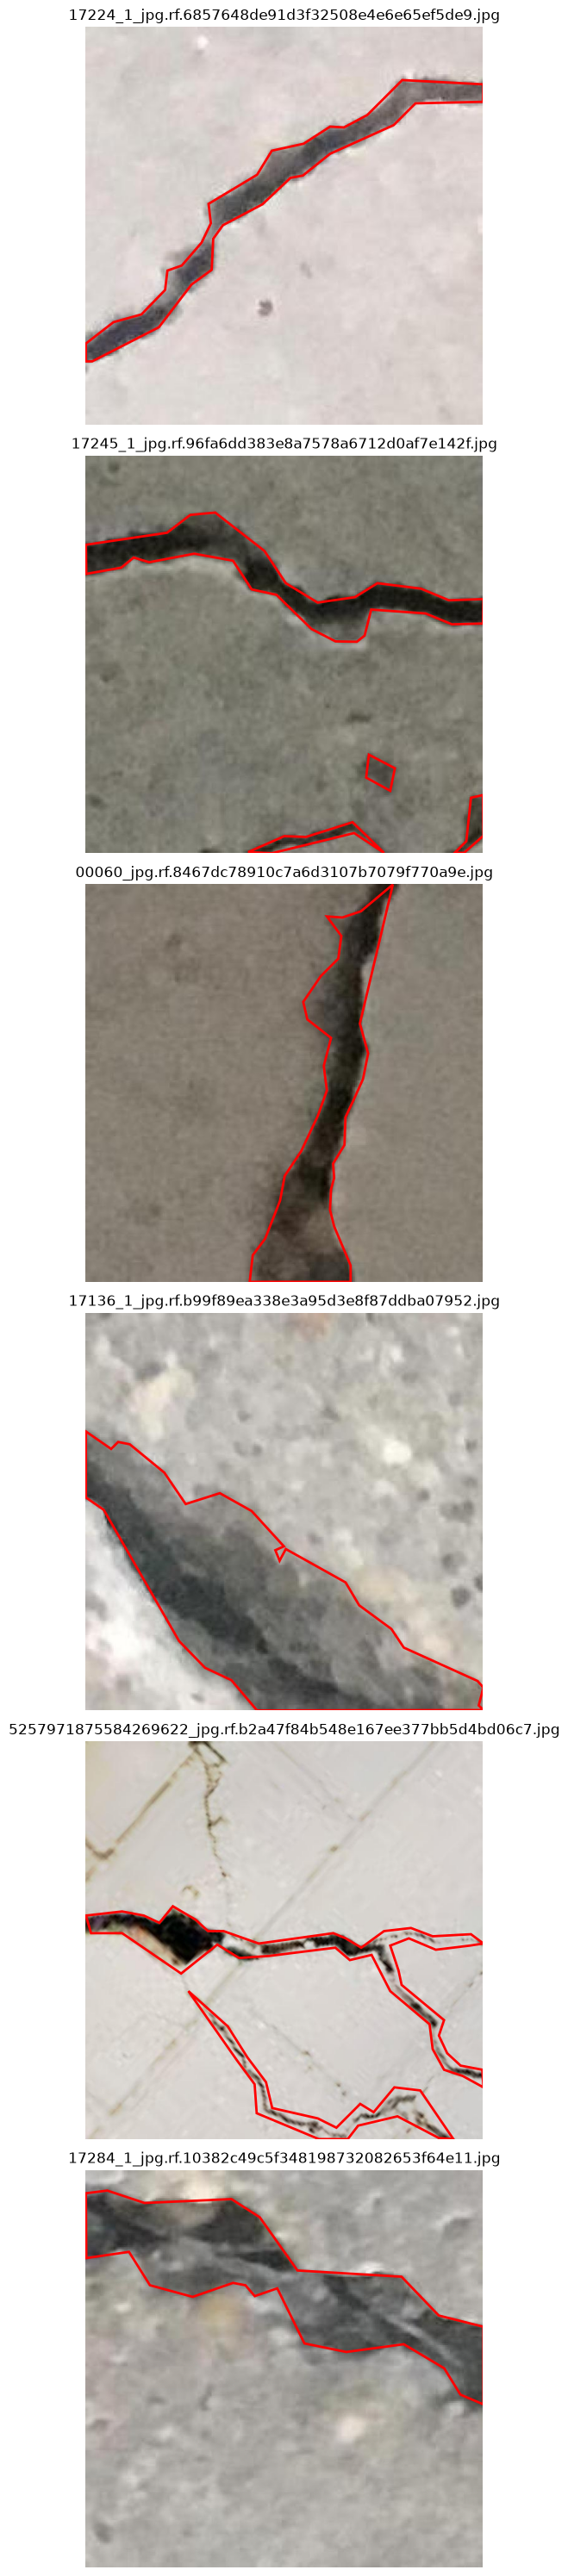

In [ ]:
PALETTE = ["red", "lime", "deepskyblue", "orange", "magenta", "yellow"]
COLORS = {i: PALETTE[i % len(PALETTE)] for i in range(len(NEW_CLASSES))}

def show_filtered_samples(image_dir, n=6):
    image_dir = Path(image_dir)
    images = get_image_files(image_dir)

    if not images:
        print(f"No images found in: {image_dir}")
        return

    selected = random.sample(images, min(n, len(images)))
    label_dir = image_dir.parent / "labels"

    fig, axes = plt.subplots(len(selected), 1, figsize=(12, 5 * len(selected)))
    if len(selected) == 1:
        axes = [axes]

    for ax, image_path in zip(axes, selected):
        image = cv2.imread(str(image_path))
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        ax.imshow(image)
        ax.set_title(image_path.name)
        ax.axis("off")

        label_path = label_dir / f"{image_path.stem}.txt"
        if label_path.exists():
            for line in label_path.read_text().splitlines():
                if not line.strip():
                    continue
                parts = list(map(float, line.split()))
                cls = int(parts[0])
                coords = parts[1:]
                color = COLORS.get(cls, "yellow")

                if len(coords) == 4:
                    xc, yc, bw, bh = coords
                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    ax.add_patch(plt.Rectangle((x1, y1), bw * w, bh * h,
                                               fill=False, linewidth=2, edgecolor=color))
                    ax.text(x1, max(y1 - 5, 0), NEW_CLASSES[cls],
                            color=color, fontsize=11, weight="bold")

                elif len(coords) >= 6 and len(coords) % 2 == 0:
                    pts = [(coords[i] * w, coords[i + 1] * h) for i in range(0, len(coords), 2)]
                    ax.add_patch(plt.Polygon(pts, fill=False, linewidth=2, edgecolor=color))

    plt.tight_layout()
    plt.show()

show_filtered_samples(FILTERED_TRAIN, n=6)

**19 — Write the training data.yaml**

In [ ]:
local_config = {
    "path": str(FILTERED_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {i: name for i, name in enumerate(NEW_CLASSES)},
}

local_yaml_path = "/content/road_crack.yaml"

with open(local_yaml_path, "w") as f:
    yaml.safe_dump(local_config, f, sort_keys=False)

print(open(local_yaml_path).read())

path: /content/datasets/crack_filtered
train: train/images
val: valid/images
test: test/images
names:
  0: crack



**20 — Pick the model**

In [ ]:
# s is a good starting point on a T4. Cracks are thin, low-contrast structures, so
# capacity helps less than input resolution — see the imgsz note in the training cell.
# Bump to "yolo26m.pt" if you have an A100/L4.
MODEL_SIZE = "s"

MODEL_WEIGHTS = (
    f"yolo26{MODEL_SIZE}-seg.pt" if IS_SEGMENTATION else f"yolo26{MODEL_SIZE}.pt"
)

print("Detected label format:", "segmentation" if IS_SEGMENTATION else "detection")
print("Model:", MODEL_WEIGHTS)

# Fallback for older ultralytics versions:
# MODEL_WEIGHTS = "yolov8s.pt"

Detected label format: segmentation
Model: yolo26s-seg.pt


**21 — Train**

Two crack-specific tweaks vs the trash notebook:

- `imgsz=768` instead of 640. Hairline cracks lose too much detail at 640; if you hit OOM on a
  T4, drop `batch` to 8 before dropping `imgsz`.
- `fliplr` / `flipud` are on, and `degrees=10` is added. A crack has no canonical orientation, so
  rotation is a safe augmentation here (it would not be for text or signage).
- `mosaic` is closed off for the last 10 epochs so the model finishes on realistic full frames.

In [ ]:
from ultralytics import YOLO

MODEL_WEIGHTS = "yolo26s.pt"

model = YOLO(MODEL_WEIGHTS)

results = model.train(
    data=local_yaml_path,
    epochs=100,
    imgsz=768,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/PTM/road_crack_training",
    name="roadCrack_v1_100E",
    patience=25
)

Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road_crack.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadCrack_v1_100E, nbs=64, nms=None, opset=None, o

**22 — Resume after a Colab disconnect** (uncomment and run)

In [ ]:
# from ultralytics import YOLO
#
# checkpoint = f"{RUN_PROJECT}/{RUN_NAME}/weights/last.pt"
# model = YOLO(checkpoint)
# results = model.train(resume=True)
#
# print("✅ Training resumed/completed.")

**23 — Validate the best checkpoint**

In [ ]:
best_model_path = f"/content/drive/MyDrive/PTM/road_crack_training/roadCrack_v1_100E/weights/best.pt"

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"best.pt not found: {best_model_path}")

trained_model = YOLO(best_model_path)

metrics = trained_model.val(
    data=local_yaml_path,
    imgsz=768,
    batch=16,
    device=0
)

print(metrics)

Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 120 layers, 9,465,567 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1007.6±496.8 MB/s, size: 28.1 KB)
val: Scanning /content/datasets/crack_filtered/valid/labels.cache... 65 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 65/65 17.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.7it/s 2.9s
                   all         65         87      0.915      0.868      0.907       0.73
Speed: 8.7ms preprocess, 17.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff1e9c377e0>
curves: ['Precision-Recall(B)', 'F1-Confide

**24 — Headline and per-class metrics**

In [ ]:
try:
    print("Precision:", metrics.results_dict.get("metrics/precision(B)"))
    print("Recall:   ", metrics.results_dict.get("metrics/recall(B)"))
    print("mAP50:    ", metrics.results_dict.get("metrics/mAP50(B)"))
    print("mAP50-95: ", metrics.results_dict.get("metrics/mAP50-95(B)"))
except Exception as e:
    print("Could not extract box metrics directly.")
    print(e)
    print(metrics.results_dict)

try:
    print("\nPer-class mAP50-95:")
    for i, ap in enumerate(metrics.box.maps):
        print(f"  {NEW_CLASSES[i]}: {ap:.4f}")
except Exception as e:
    print("Per-class metrics unavailable:", e)

Precision: 0.9151567969154603
Recall:    0.8679099504213831
mAP50:     0.9066362114246994
mAP50-95:  0.7300256089897845

Per-class mAP50-95:
  crack: 0.7300


**25 — Predict on your own images**

For cracks, `conf=0.25` is often too strict — thin cracks come back at 0.15–0.3. Look at the
precision/recall curve in the run folder before locking a threshold.

In [ ]:
CUSTOM_FOLDER = "/content/drive/MyDrive/PTM/images/road"

results = trained_model.predict(
    source=CUSTOM_FOLDER,
    imgsz=768,
    conf=0.20,
    save=True
)

print("Saved to:", results[0].save_dir if results else "no images found")


image 1/14 /content/drive/MyDrive/PTM/images/road/p1.jpg: 512x768 2 cracks, 15.8ms
image 2/14 /content/drive/MyDrive/PTM/images/road/p10.jpg: 480x768 1 crack, 59.4ms
image 3/14 /content/drive/MyDrive/PTM/images/road/p11.jpg: 512x768 4 cracks, 16.9ms
image 4/14 /content/drive/MyDrive/PTM/images/road/p12.jpg: 448x768 1 crack, 72.3ms
image 5/14 /content/drive/MyDrive/PTM/images/road/p13.jpg: 512x768 1 crack, 16.7ms
image 6/14 /content/drive/MyDrive/PTM/images/road/p14.jpg: 448x768 2 cracks, 16.3ms
image 7/14 /content/drive/MyDrive/PTM/images/road/p2.jpg: 320x768 1 crack, 59.1ms
image 8/14 /content/drive/MyDrive/PTM/images/road/p3.jpg: 544x768 1 crack, 61.7ms
image 9/14 /content/drive/MyDrive/PTM/images/road/p4.jpg: 512x768 1 crack, 17.0ms
image 10/14 /content/drive/MyDrive/PTM/images/road/p5.jpg: 320x768 1 crack, 21.7ms
image 11/14 /content/drive/MyDrive/PTM/images/road/p6.jpg: 608x768 3 cracks, 60.3ms
image 12/14 /content/drive/MyDrive/PTM/images/road/p7.jpg: 512x768 1 crack, 16.8ms
ima

**26 — Display the predictions**

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

folder = str(results[0].save_dir)   # or hardcode e.g. "/content/runs/detect/predict"

images = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

print("Total images:", len(images))

for image_path in images:
    img = Image.open(image_path)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

**27 — Export for deployment** (optional)

In [ ]:
# ONNX for most runtimes; TFLite/NCNN if you are going to a phone or a Pi.
onnx_path = trained_model.export(format="onnx", imgsz=768, opset=12)
print("Exported:", onnx_path)

# trained_model.export(format="tflite", imgsz=768)
# trained_model.export(format="ncnn",   imgsz=768)